In [78]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import random
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter

In [62]:
# Paths
DATA_DIR = Path('../../data')
DATA_FILES_DIR = DATA_DIR / 'data_files'
LABELS_FILE = DATA_DIR / 'data_info' / 'data_roster.csv'

IMAGE_HEIGHT = 132
IMAGE_WIDTH = 164

print(f"Data directory exists: {DATA_FILES_DIR.exists()}")
print(f"Labels file exists: {LABELS_FILE.exists()}")

Data directory exists: True
Labels file exists: True


In [63]:
# Load labels
labels_df = pd.read_csv(LABELS_FILE, index_col=0)
print(f"Labels dataframe shape: {labels_df.shape}")
labels_df.head()

Labels dataframe shape: (16478, 12)


,file_name,label_v1,3-agree,label_v2,label_v3,excitation_position,excitation_PIE,excitation_quality,soldet_CNN,soldet_OD,soldet_PIE,soldet_QE
/data/data_files/class-1/2019-08-02_0004_20190523_BEC_F1_NewODT_DMD_42.npy,/data/data_files/class-1/2019-08-02_0004_20190...,1,1,1,1,[110.35077157540614],[1],[0.7305203942861915],NaN,NaN,NaN,NaN
/data/data_files/class-1/2019-07-19_0028_20190523_BEC_F1_NewODT_DMD_037.npy,/data/data_files/class-1/2019-07-19_0028_20190...,1,0,1,1,[41.63773334829051],[1],[0.24901817761481015],NaN,NaN,NaN,NaN
/data/data_files/class-0/2019-07-16_0012_20190523_BEC_F1_NewODT_DMD_208.npy,/data/data_files/class-0/2019-07-16_0012_20190...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/data/data_files/class-2/2019-07-15_0011_20190523_BEC_F1_NewODT_DMD_025.npy,/data/data_files/class-2/2019-07-15_0011_20190...,2,1,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
/data/data_files/class-0/2019-07-12_0061_20190523_BEC_F1_NewODT_DMD_109.npy,/data/data_files/class-0/2019-07-12_0061_20190...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
def load_bec_dataset(data_dir, labels_df, max_samples=None, shuffle_seed=42):
    """Load BEC images + labels from data_files and data_roster.csv."""
    class_dirs = [d for d in data_dir.glob('class-*') if d.is_dir()]

    def class_sort_key(path_obj):
        suffix = path_obj.name.split('-')[-1]
        return int(suffix) if suffix.isdigit() else suffix

    class_dirs = sorted(class_dirs, key=class_sort_key)
    print(f"Discovered class folders: {[d.name for d in class_dirs]}")

    all_files = []
    for class_dir in class_dirs:
        all_files.extend(sorted(class_dir.glob('*.npy')))

    print(f"Found {len(all_files)} .npy files")

    if shuffle_seed is not None:
        random.seed(shuffle_seed)
        random.shuffle(all_files)

    if max_samples is not None:
        all_files = all_files[:max_samples]

    images = []
    labels = []
    positions = []
    file_paths = []

    print(f"Loading {len(all_files)} samples...")
    for file_path in tqdm(all_files):
        try:
            data_dict = np.load(file_path, allow_pickle=True).item()
            img = data_dict['cloud_data'].reshape(IMAGE_HEIGHT, IMAGE_WIDTH, 1)

            rel_path = '/data/' + '/'.join(file_path.parts[-3:])
            if rel_path in labels_df.index:
                label_row = labels_df.loc[rel_path]
                label = int(label_row['label_v3'])

                pos_str = label_row['excitation_position']
                if pd.isna(pos_str) or pos_str == '':
                    pos = []
                else:
                    try:
                        pos = eval(pos_str) if isinstance(pos_str, str) else []
                        if not isinstance(pos, list):
                            pos = [pos] if pos else []
                    except Exception:
                        pos = []

                images.append(img.astype(np.float32))
                labels.append(label)
                positions.append(pos)
                file_paths.append(str(file_path))
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            continue

    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)

    print(f"Loaded {len(images)} images")
    print(f"Image shape: {images.shape}")
    print(f"Value range: [{images.min():.3f}, {images.max():.3f}]")
    print(f"Label distribution: {np.bincount(labels)}")

    return images, labels, positions, file_paths

In [65]:
# Load dataset
images, labels, positions, file_paths = load_bec_dataset(
    DATA_FILES_DIR,
    labels_df,
    max_samples=None,
    shuffle_seed=42,
    )

print(f"Unique labels: {np.unique(labels)}")
print(f"images dtype: {images.dtype}")

Discovered class folders: ['class-0', 'class-1', 'class-2', 'class-8', 'class-9']
Found 16478 .npy files
Loading 16478 samples...


100%|██████████| 16478/16478 [05:17<00:00, 51.85it/s]


Loaded 16478 images
Image shape: (16478, 132, 164, 1)
Value range: [-0.479, 3.492]
Label distribution: [ 1130  3212  1036     0     0     0     0     0   879 10221]
Unique labels: [0 1 2 8 9]
images dtype: float32


In [66]:
# Utility: pick one anchor image index for parameter fitting
anchor_idx = 0
print(f"Anchor sample index: {anchor_idx}")

Anchor sample index: 0


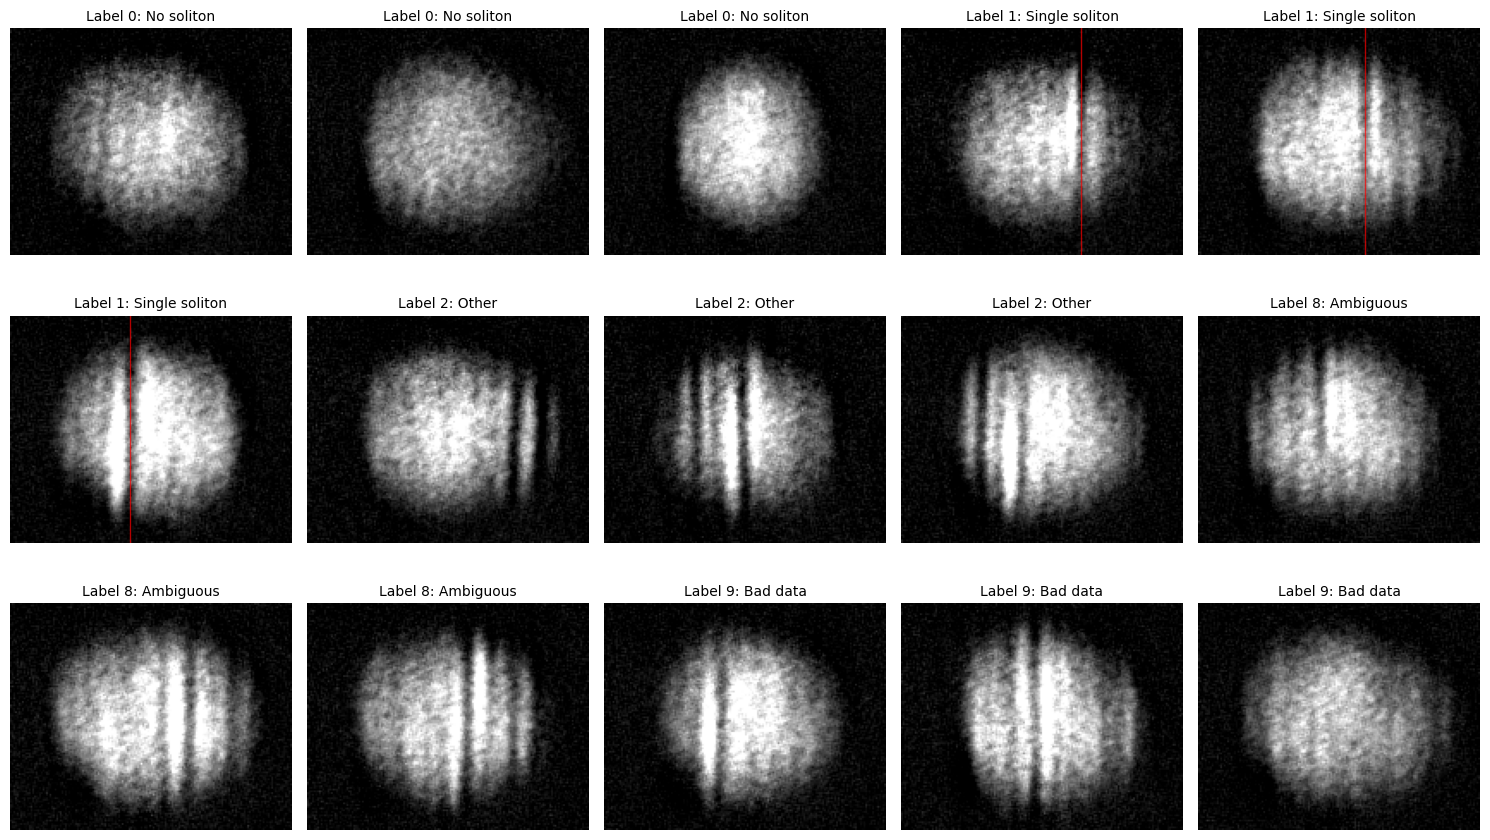

In [67]:
# Preview a few real images
class_values = sorted(np.unique(labels).tolist())
samples_per_class = 3
max_total_plots = 15
n_cols = 5
n_rows = int(np.ceil(max_total_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 9))
axes = axes.flatten()

label_names = {0: 'No soliton', 1: 'Single soliton', 2: 'Other', 8: 'Ambiguous', 9: 'Bad data'}
plot_idx = 0

for label_val in class_values:
    indices = np.where(labels == label_val)[0]
    if len(indices) == 0:
        continue

    sample_indices = indices[:min(samples_per_class, len(indices))]
    for idx in sample_indices:
        if plot_idx >= max_total_plots:
            break
        img = images[idx].squeeze()
        axes[plot_idx].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[plot_idx].set_title(f"Label {label_val}: {label_names.get(label_val, f'Class {label_val}')}", fontsize=10)
        axes[plot_idx].axis('off')

        if len(positions[idx]) > 0:
            for pos in positions[idx]:
                axes[plot_idx].axvline(x=pos, color='red', linewidth=1, alpha=0.7)

        plot_idx += 1

for idx in range(plot_idx, max_total_plots):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [295]:
# Thomas-Fermi model and fitting helpers
def thomas_fermi_2d(coords, n0, i0, j0, Ri, Rj, theta, delta_n):
    i, j = coords
    di = i - i0
    dj = j - j0

    cos_t = np.cos(theta)
    sin_t = np.sin(theta)
    i_theta = cos_t * di + sin_t * dj
    j_theta = -sin_t * di + cos_t * dj

    inside = 1.0 - (i_theta / Ri) ** 2 - (j_theta / Rj) ** 2
    tf_core = np.maximum(inside, 0.0) ** 1.5
    return n0 * tf_core + delta_n

def fit_thomas_fermi_image(image_2d):
    h, w = image_2d.shape
    i_grid, j_grid = np.indices((h, w))

    data_min = float(np.min(image_2d))
    data_max = float(np.max(image_2d))
    data_range = max(data_max - data_min, 1e-6)

    p0 = np.array([
        data_range,
        (h - 1) / 2.0,
        (w - 1) / 2.0,
        max(h / 3.0, 1.0),
        max(w / 3.0, 1.0),
        0.0,
        data_min,
    ], dtype=float)

    lower = np.array([0.0, 0.0, 0.0, 1.0, 1.0, -np.pi / 2, data_min - 0.5 * data_range], dtype=float)
    upper = np.array([data_max + 2.0 * data_range, h - 1.0, w - 1.0, 2.0 * h, 2.0 * w, np.pi / 2, data_max], dtype=float)

    eps = 1e-9
    p0 = np.minimum(np.maximum(p0, lower + eps), upper - eps)

    popt, _ = curve_fit(
        thomas_fermi_2d,
        (i_grid.ravel(), j_grid.ravel()),
        image_2d.ravel(),
        p0=p0,
        bounds=(lower, upper),
        method='trf',
        maxfev=30000,
    )

    fitted = thomas_fermi_2d((i_grid, j_grid), *popt)
    residual = image_2d - fitted
    return popt, fitted, residual

def sample_thomas_fermi_cloud(tf_params, shape=(IMAGE_HEIGHT, IMAGE_WIDTH), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    n0, i0, j0, Ri, Rj, theta, delta_n = tf_params
    h, w = shape

    sampled = [
        n0 * rng.uniform(0.9, 1.1),
        i0 + rng.uniform(-3.0, 3.0),
        j0 + rng.uniform(-3.0, 3.0),
        Ri * rng.uniform(0.9, 1.1),
        Rj * rng.uniform(0.9, 1.1),
        theta + rng.uniform(-0.12, 0.12),
        delta_n + rng.uniform(-0.01, 0.01),
    ]

    i_grid, j_grid = np.indices((h, w))
    cloud = thomas_fermi_2d((i_grid, j_grid), *sampled)
    return np.clip(cloud, 0.0, 1.0), sampled

In [369]:
# Simulation components: soliton, diffraction, shot noise, read noise
def add_dark_soliton_excitation(
    image,
    i0,
    j0,
    angle_rad=0.0,
    depth=0.70,
    width_px=3.0,
    fringe_gain=0.14,
    fringe_period_px=7.0,
    fringe_decay_px=10.0,
    fringe_phase=0.0,
    side_antisym=0.0,
    side_antisym_scale_px=4.0,
    diagonal_antisym=0.0,
    diagonal_antisym_scale_px=12.0,
    diagonal_angle_rad=0.0,
    y_fade_px=None,
    y_fade_power=2.0,
    ):
    """
    Dark soliton notch plus optional side-lobe ringing.
    angle_rad=0 is vertical/y-axis aligned.
    Ringing is centered at -1 at the notch core (d=0).

    Antisymmetry controls:
      - side_antisym: imbalance across the soliton normal direction (left/right of notch).
      - diagonal_antisym: TL+BR versus TR+BL lobe imbalance around the soliton center.

    y_fade_px applies an along-line taper centered at (i0, j0), so the excitation
    fades in the y direction (for angle_rad ~= 0) away from the soliton position.
    """
    h, w = image.shape
    i_grid, j_grid = np.indices((h, w))

    # d: coordinate normal to the soliton line, t: coordinate along the soliton line.
    d = (j_grid - j0) * np.cos(angle_rad) - (i_grid - i0) * np.sin(angle_rad)
    t = (j_grid - j0) * np.sin(angle_rad) + (i_grid - i0) * np.cos(angle_rad)

    if y_fade_px is not None and y_fade_px > 0:
        t_scale = max(float(y_fade_px), 1e-3)
        fade_power = max(float(y_fade_power), 1e-3)
        y_fade = np.exp(-0.5 * (np.abs(t) / t_scale) ** fade_power)
    else:
        y_fade = 1.0

    width_eff = max(float(width_px), 1e-3)
    notch = np.exp(-(d ** 2) / (2.0 * width_eff ** 2))
    notch = notch * y_fade
    depletion = image * (1.0 - depth * notch)

    if fringe_gain is None or fringe_gain <= 0:
        return np.clip(depletion, 0.0, 1.0)

    period = max(float(fringe_period_px), 1e-3)
    decay = max(float(fringe_decay_px), 1e-3)
    envelope = np.exp(-(d ** 2) / (2.0 * decay ** 2))
    envelope = envelope * y_fade

    # Center at -1 when d=0 and fringe_phase=0.
    ringing = -np.cos((2.0 * np.pi * d / period) + fringe_phase) * envelope

    # Smoothly rebalance lobe amplitudes on opposite sides of the notch.
    side_scale = max(float(side_antisym_scale_px), 1e-3)
    side_field = np.tanh(d / side_scale)

    # Diagonal quadrants (+ in TL/BR, - in TR/BL when diagonal_angle_rad=0).
    ii = i_grid - i0
    jj = j_grid - j0
    x_diag = jj * np.cos(diagonal_angle_rad) - ii * np.sin(diagonal_angle_rad)
    y_diag = jj * np.sin(diagonal_angle_rad) + ii * np.cos(diagonal_angle_rad)
    diag_scale = max(float(diagonal_antisym_scale_px), 1e-3)
    diag_field = np.tanh((x_diag * y_diag) / (diag_scale ** 2))

    amplitude_mod = 1.0 + side_antisym * side_field + diagonal_antisym * diag_field
    amplitude_mod = np.clip(amplitude_mod, 0.0, 2.5)

    ringing = np.clip(ringing * amplitude_mod, -1.0, 1.0)

    out = depletion + fringe_gain * ringing * image
    return out

def apply_fresnel_diffraction(
    image, wavelength=780e-9, pixel_size=5.6e-6, propagation_distance=2.0e-3, phase_scale=1.2, blend=0.7, na=0.22
    ):
    img = np.clip(image.astype(np.float64), 0.0, 1.0)
    h, w = img.shape

    amplitude = np.sqrt(img + 1e-8)
    phase = phase_scale * img
    field0 = amplitude * np.exp(1j * phase)

    fy = np.fft.fftfreq(h, d=pixel_size)
    fx = np.fft.fftfreq(w, d=pixel_size)
    FX, FY = np.meshgrid(fx, fy)

    H = np.exp(-1j * np.pi * wavelength * propagation_distance * (FX**2 + FY**2))
    if na is not None and na > 0:
        f_cut = na / wavelength
        H = H * ((FX**2 + FY**2) <= (f_cut**2))

    field_z = np.fft.ifft2(np.fft.fft2(field0) * H)
    intensity_z = np.abs(field_z) ** 2
    intensity_z = intensity_z - intensity_z.min()
    if intensity_z.max() > 0:
        intensity_z = intensity_z / intensity_z.max()

    out = (1.0 - blend) * img + blend * intensity_z
    return out

def add_shot_noise(image, photons_per_pixel=5, rng=None):
    """Poisson shot noise: variance grows with intensity."""
    if rng is None:
        rng = np.random.default_rng()
    img = np.clip(image, 0.0, 1.0)
    expected_counts = img * photons_per_pixel
    noisy_counts = rng.poisson(expected_counts)
    noisy = noisy_counts / photons_per_pixel
    return noisy

def add_read_noise(image, read_noise_std=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    noisy = image + rng.normal(0.0, read_noise_std, size=image.shape)
    return noisy

def add_shift(image, max_shift_px=5.0, rng=None):
    """this function simulates ghosting by randomly choosing 
    whether to add a shifted version of the image on the image or not. The probabiity to do
    the shift is 0.5. The shift is randmly chosen in both directions."""
    if rng is None:
        rng = np.random.default_rng()

    if rng.random() < 0.9:
        shift_i = rng.uniform(-max_shift_px, max_shift_px)
        shift_j = rng.uniform(-max_shift_px, max_shift_px)

        shifted_image = np.roll(image, shift=(int(shift_i), int(shift_j)), axis=(0, 1))
        blended = 0.5 * image + 0.5 * shifted_image
        return blended

    return image

def add_exposure_variation(
    image,
    rng=None,
    base_gain_range=(0.9, 1.12),
    overexposure_prob=0.2,
    overexposure_gain_range=(1.12, 1.22),
):
    """Apply mild exposure spread with occasional slight overexposure."""
    if rng is None:
        rng = np.random.default_rng()

    gain = rng.uniform(*base_gain_range)
    if rng.random() < overexposure_prob:
        gain = rng.uniform(*overexposure_gain_range)

    exposed = image * gain
    return exposed

def add_gaussian_blur(image, gaussian_sigma=0.0):
    """Apply Gaussian filtering with variable width (sigma in pixels)."""
    if gaussian_sigma is None or gaussian_sigma <= 0:
        return np.clip(image, 0.0, 1.0)
    blurred = gaussian_filter(image, sigma=gaussian_sigma, mode='reflect')
    return blurred

def simulate_bec_image(
    tf_params,
    add_soliton=True,
    num_solitons=1,
    base_soliton_angle=0.0,
    angle_jitter_deg=1.0,
    shot_photons=4,
    read_noise_std=0.035,
    gaussian_sigma=0.8,
    pixel_size=5.6e-6,
    rng=None,
    ):
    if rng is None:
        rng = np.random.default_rng()

    img, sampled_params = sample_thomas_fermi_cloud(tf_params, rng=rng)
    n0, i0, j0, Ri, Rj, theta, delta_n = sampled_params
    soliton_specs = []

    if add_soliton and num_solitons > 0:
        jitter_rad = np.deg2rad(angle_jitter_deg)
        for _ in range(num_solitons):
            angle = base_soliton_angle + rng.uniform(-jitter_rad, jitter_rad)
            si = i0 + rng.uniform(-0.4 * Ri, 0.4 * Ri)
            sj = j0 + rng.uniform(-0.4 * Rj, 0.4 * Rj)
            depth = rng.uniform(0.65, 0.80)
            width = rng.uniform(0.8, 1.4)

            # Side-lobe controls; phase near zero keeps core centered at -1.
            fringe_gain = rng.uniform(1.3, 1.7)
            fringe_period_px = rng.uniform(11.0, 13.0)
            fringe_decay_px = rng.uniform(5.0, 10.0)
            fringe_phase = rng.uniform(-0.02, 0.02)

            # Antisymmetric lobe controls.
            side_antisym = rng.uniform(-0.85, 0.85) if rng.random() < 0.75 else 0.0
            side_antisym_scale_px = rng.uniform(5.0, 15.0)
            diagonal_antisym = rng.uniform(-0.4, 0.4) if rng.random() < 0.55 else 0.0
            diagonal_antisym_scale_px = rng.uniform(10.0, 22.0)
            diagonal_angle_rad = rng.uniform(-np.pi /20.0, np.pi / 20.0)

            # Along-line taper (angle~=0 means y-direction fade around i0).
            y_fade_px = rng.uniform(25.0, 35.0)
            y_fade_power = rng.uniform(1.7, 2.0)

            img = add_dark_soliton_excitation(
                img,
                si,
                sj,
                angle_rad=angle,
                depth=depth,
                width_px=width,
                fringe_gain=fringe_gain,
                fringe_period_px=fringe_period_px,
                fringe_decay_px=fringe_decay_px,
                fringe_phase=fringe_phase,
                side_antisym=side_antisym,
                side_antisym_scale_px=side_antisym_scale_px,
                diagonal_antisym=diagonal_antisym,
                diagonal_antisym_scale_px=diagonal_antisym_scale_px,
                diagonal_angle_rad=diagonal_angle_rad,
                y_fade_px=y_fade_px,
                y_fade_power=y_fade_power,
            )

            soliton_specs.append({
                'i': float(si),
                'j': float(sj),
                'angle_deg': float(np.rad2deg(angle)),
                'depth': float(depth),
                'width_px': float(width),
                'fringe_gain': float(fringe_gain),
                'fringe_period_px': float(fringe_period_px),
                'fringe_decay_px': float(fringe_decay_px),
                'fringe_phase': float(fringe_phase),
                'side_antisym': float(side_antisym),
                'side_antisym_scale_px': float(side_antisym_scale_px),
                'diagonal_antisym': float(diagonal_antisym),
                'diagonal_antisym_scale_px': float(diagonal_antisym_scale_px),
                'diagonal_angle_deg': float(np.rad2deg(diagonal_angle_rad)),
                'y_fade_px': None if y_fade_px is None else float(y_fade_px),
                'y_fade_power': float(y_fade_power),
            })

    propagation_distance = rng.uniform(1.2e-3, 3.0e-3)
    phase_scale = rng.uniform(0.6, 0.9)
    blend = rng.uniform(0.6, 0.9)

    img = apply_fresnel_diffraction(
        img,
        wavelength=780e-9,
        pixel_size=pixel_size,
        propagation_distance=propagation_distance,
        phase_scale=phase_scale,
        blend=blend,
        na=0.22,
    )
    img = add_exposure_variation(
        img,
        rng=rng,
        base_gain_range=(0.9, 1.12),
        overexposure_prob=1.0,
        overexposure_gain_range=(1.12, 1.42),
    )
    img = add_shot_noise(img, photons_per_pixel=shot_photons, rng=rng)
    img = add_shift(img, max_shift_px=6.0, rng=rng)
    img = add_gaussian_blur(img, gaussian_sigma=gaussian_sigma)
    img = add_read_noise(img, read_noise_std=read_noise_std, rng=rng)
    
    metadata = {
        'num_excitations': int(num_solitons if add_soliton else 0),
        'tf': {
            'n0': float(n0),
            'i0': float(i0),
            'j0': float(j0),
            'Ri': float(Ri),
            'Rj': float(Rj),
            'theta_deg': float(np.rad2deg(theta)),
            'delta_n': float(delta_n),
        },
        'fresnel': {
            'pixel_size': float(pixel_size),
            'propagation_distance': float(propagation_distance),
            'phase_scale': float(phase_scale),
            'blend': float(blend),
        },
        'shot_photons': int(shot_photons),
        'read_noise_std': float(read_noise_std),
        'gaussian_sigma': float(gaussian_sigma),
        'solitons': soliton_specs,
    }

    return img, metadata

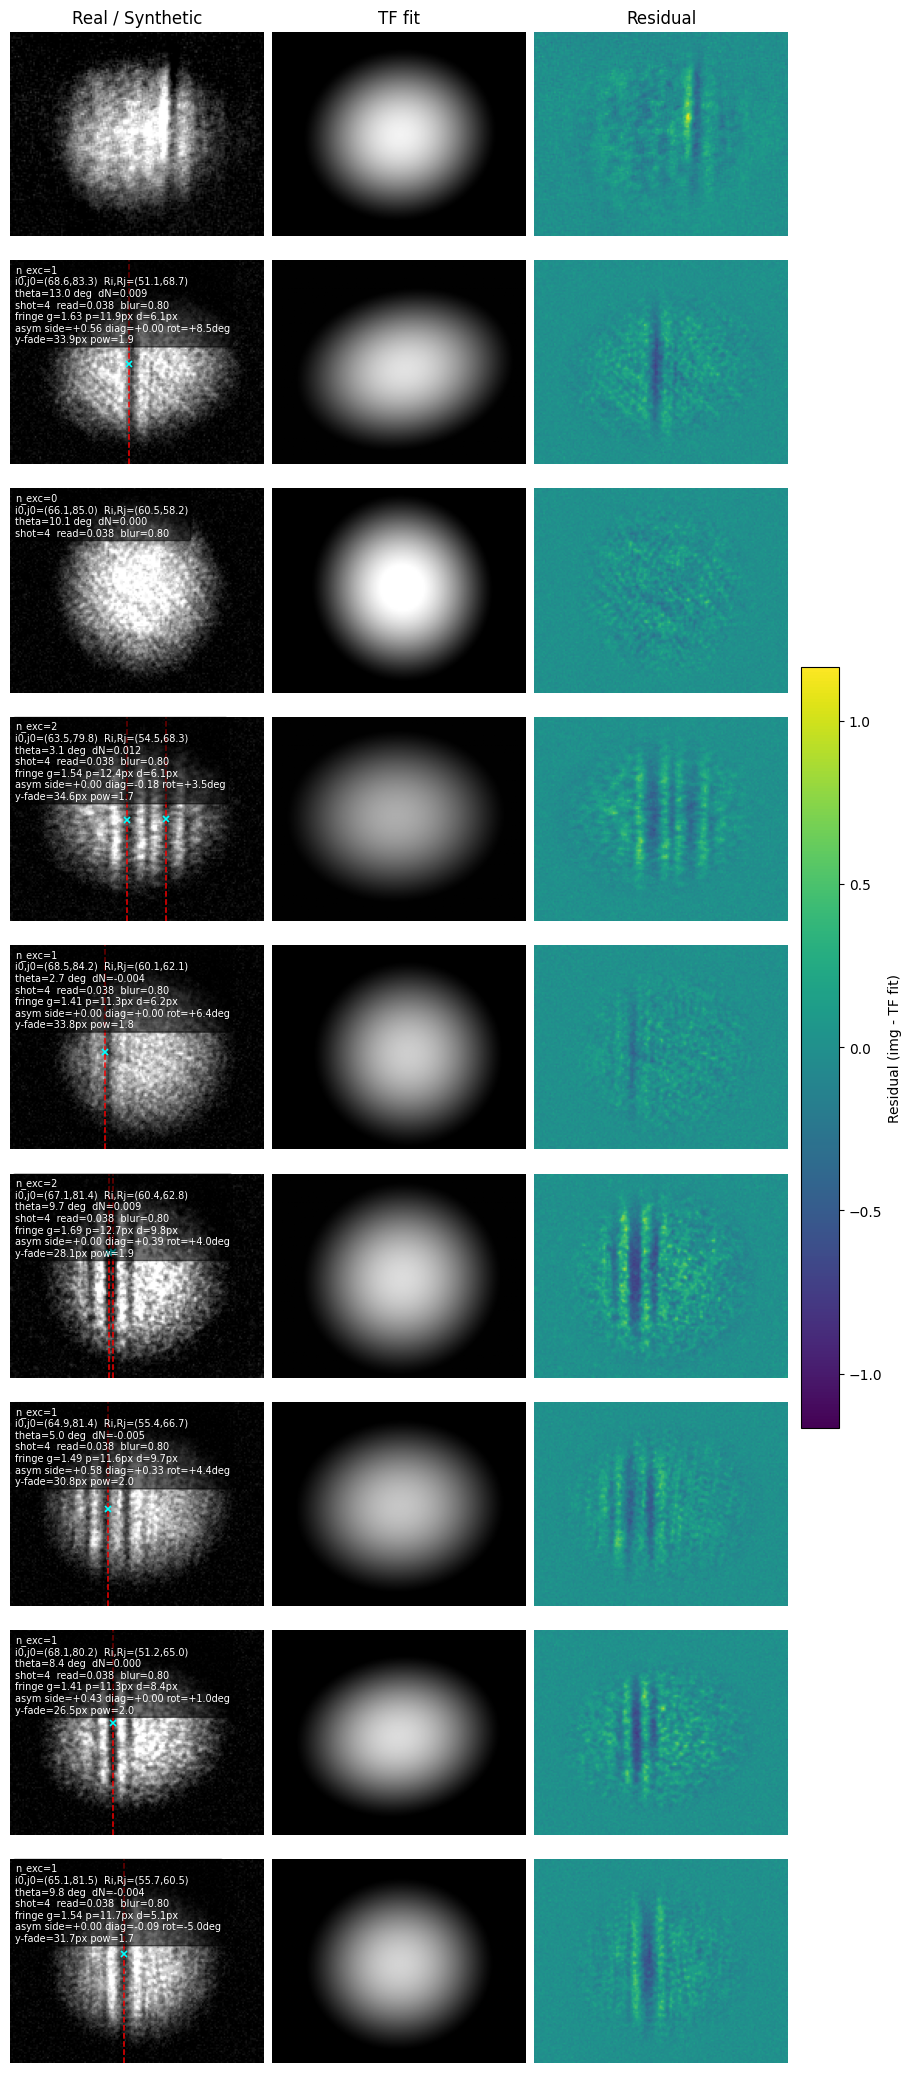

In [ ]:
# Simulate images
anchor_img = images[anchor_idx].squeeze()
anchor_params, anchor_fit, anchor_res = fit_thomas_fermi_image(anchor_img)

rng = np.random.default_rng(42)
n_synth = 8
gaussian_sigma = 0.8  # filter width in pixels (set 0 to disable)
synth_images = []
synth_fits = []
synth_residuals = []
synth_metadata = []

for _ in range(n_synth):
    n_sol = rng.choice([0, 1, 2], p=[0.2, 0.6, 0.2])
    sim, sim_meta = simulate_bec_image(
        anchor_params,
        add_soliton=(n_sol > 0),
        num_solitons=n_sol,
        base_soliton_angle=0.0,
        angle_jitter_deg=1.0,
        shot_photons=4,
        read_noise_std=0.038,
        gaussian_sigma=gaussian_sigma,
        rng=rng,
    )
    _, sim_fit, sim_res = fit_thomas_fermi_image(sim)
    synth_images.append(sim)
    synth_fits.append(sim_fit)
    synth_residuals.append(sim_res)
    synth_metadata.append(sim_meta)

# Stack rows as: [real/synthetic, fit, residual] per sample.
row_labels = ['Anchor'] + [f'Synth {k}' for k in range(1, n_synth + 1)]
real_stack = [anchor_img] + synth_images
fit_stack = [anchor_fit] + synth_fits
res_stack = [anchor_res] + synth_residuals
meta_stack = [None] + synth_metadata

n_rows = len(row_labels)
fig, axes = plt.subplots(n_rows, 3, figsize=(9.0, 2.3 * n_rows), constrained_layout=True)

# Keep one symmetric residual color scale across all residual plots.
residual_limit = max(np.max(np.abs(r)) for r in res_stack)

for r, (label, real_img, fit_img, res_img, meta) in enumerate(zip(row_labels, real_stack, fit_stack, res_stack, meta_stack)):
    axes[r, 0].imshow(real_img, cmap='gray', vmin=0, vmax=1)
    axes[r, 1].imshow(fit_img, cmap='gray', vmin=0, vmax=1)
    residual_im = axes[r, 2].imshow(res_img, cmap='viridis', vmin=-residual_limit, vmax=residual_limit)

    for c in range(3):
        axes[r, c].axis('off')

    axes[r, 0].set_ylabel(label, rotation=90, fontsize=11, labelpad=12, va='center')

    if meta is not None:
        tf = meta['tf']
        info_lines = [
            f"n_exc={meta['num_excitations']}",
            f"i0,j0=({tf['i0']:.1f},{tf['j0']:.1f})  Ri,Rj=({tf['Ri']:.1f},{tf['Rj']:.1f})",
            f"theta={tf['theta_deg']:.1f} deg  dN={tf['delta_n']:.3f}",
            f"shot={meta['shot_photons']}  read={meta['read_noise_std']:.3f}  blur={meta['gaussian_sigma']:.2f}",
        ]
        if meta['num_excitations'] > 0 and len(meta['solitons']) > 0:
            s0 = meta['solitons'][0]
            info_lines.append(
                f"fringe g={s0['fringe_gain']:.2f} p={s0['fringe_period_px']:.1f}px d={s0['fringe_decay_px']:.1f}px"
            )
            info_lines.append(
                f"asym side={s0['side_antisym']:+.2f} diag={s0['diagonal_antisym']:+.2f} rot={s0['diagonal_angle_deg']:+.1f}deg"
            )
            y_fade_label = 'off' if s0['y_fade_px'] is None else f"{s0['y_fade_px']:.1f}px"
            info_lines.append(
                f"y-fade={y_fade_label} pow={s0['y_fade_power']:.1f}"
            )
        axes[r, 0].text(
            0.02,
            0.98,
            '\n'.join(info_lines),
            transform=axes[r, 0].transAxes,
            va='top',
            ha='left',
            fontsize=7,
            color='white',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='black', alpha=0.55),
        )

        if meta['num_excitations'] > 0:
            for sol in meta['solitons']:
                axes[r, 0].axvline(sol['j'], color='red', linestyle='--', linewidth=1.1, alpha=0.95)
                axes[r, 0].plot(sol['j'], sol['i'], marker='x', color='cyan', markersize=5, mew=1.2)

axes[0, 0].set_title('Original')
axes[0, 1].set_title('TF fit')
axes[0, 2].set_title('Residual')

fig.colorbar(residual_im, ax=axes[:, 2], shrink=0.9, label='Residual (img - TF fit)')
plt.show()

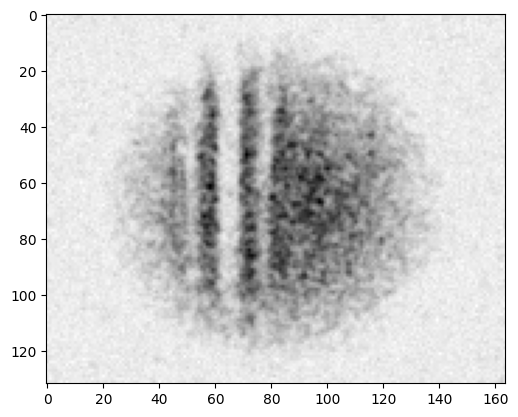

In [372]:
plt.imshow(synth_images[4], cmap='gray_r')